# Realistic Execution Backtest (Full History)

In this notebook, we evaluate the performance of the selected intraday strategies over the full available dataset (2018–April 2026), incorporating realistic execution assumptions.

Unlike previous analyses, this step includes transaction costs and applies a more conservative backtesting framework in order to approximate real-world trading conditions more closely.

The objective is to assess whether the observed intraday bias remains profitable after accounting for execution frictions and when tested over the entire sample history.

In [3]:
import pandas as pd

import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

from src.backtest import run_backtest, compute_metrics, generate_position, backtest_strategies
from src.plotting import format_results_table, plot_equity_drawdown_grid

In [12]:
# Load EURUSD H1 dataset
df = pd.read_csv("../data/eurusd_h1.csv")

# Load the CSV file containing the top 4 strategies
# previously selected during the optimization phase
top4 = pd.read_csv("../data/top4_strategies.csv")

In [13]:
# Convert the selected strategies into a list of dictionaries
# Each dictionary contains the entry and exit hours
# for a single strategy configuration
strategies = top4[["entry_hour", "exit_hour"]].to_dict("records")

In [14]:
# sanity check
strategies

[{'entry hour': 1, 'exit hour': 2},
 {'entry hour': 0, 'exit hour': 2},
 {'entry hour': 1, 'exit hour': 3},
 {'entry hour': 0, 'exit hour': 3}]

In [15]:
# Convert timestamp column to datetime format
df["time"] = pd.to_datetime(df["time"])

# Set datetime as index for time-series operations
df = df.set_index("time")

# Rename price column to a standard name used in the backtest engine
df = df.rename(columns={"close": "price"})

# Keep only relevant column for strategy/backtest
df = df[["price"]]

# Extract hour of day from datetime index to construct entry/exit trading signals
df["hour"] = df.index.hour

In [16]:
# Quick sanity check of the dataset structure

display(df.head())

df.info()

,price,hour
time,,
2018-04-06 08:00:00,1.22374,8
2018-04-06 09:00:00,1.22357,9
2018-04-06 10:00:00,1.22270,10
2018-04-06 11:00:00,1.22350,11
2018-04-06 12:00:00,1.22430,12


<class 'pandas.DataFrame'>
DatetimeIndex: 50000 entries, 2018-04-06 08:00:00 to 2026-04-24 10:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   50000 non-null  float64
 1   hour    50000 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 976.6 KB


## Transaction Costs Assumptions

To make the backtest more realistic, we incorporate the following trading costs:

- Bid/ask spread
- Broker commissions
- Execution slippage

EUR/USD is a highly liquid currency pair, therefore transaction costs are assumed to be relatively low but non-negligible.

### Cost Model

- Estimated bid/ask spread cost: **0.00003**
- Estimated broker commission cost (Interactive Brokers pricing are approximately 2 USD per 100,000 traded): **0.00002**
- Estimated execution slippage: **0.00001**

### Total Estimated Cost per Trade

**Total Cost = 0.00006**

In [2]:
# Estimated bid/ask spread cost
SPREAD_COST = 0.00003

# Estimated broker commission cost
COMMISSION_COST = 0.00002

# Estimated execution slippage
SLIPPAGE_COST = 0.00001

TOTAL_COST = SPREAD_COST + COMMISSION_COST + SLIPPAGE_COST

In [18]:
# Run the backtest on all selected strategies
results_df, equity_curves = backtest_strategies(df, strategies, TOTAL_COST)

In [19]:
# Display the results table with formatted values
format_results_table(results_df)

,Annualized Return,Annualized Volatility,Max Drawdown,Sharpe Ratio,Calmar Ratio
strategy,,,,,
1-2,0.36%,0.94%,-2.13%,0.39,0.17
0-2,0.56%,1.50%,-5.22%,0.38,0.11
1-3,0.17%,1.39%,-5.38%,0.12,0.03
0-3,0.37%,1.81%,-7.44%,0.20,0.05


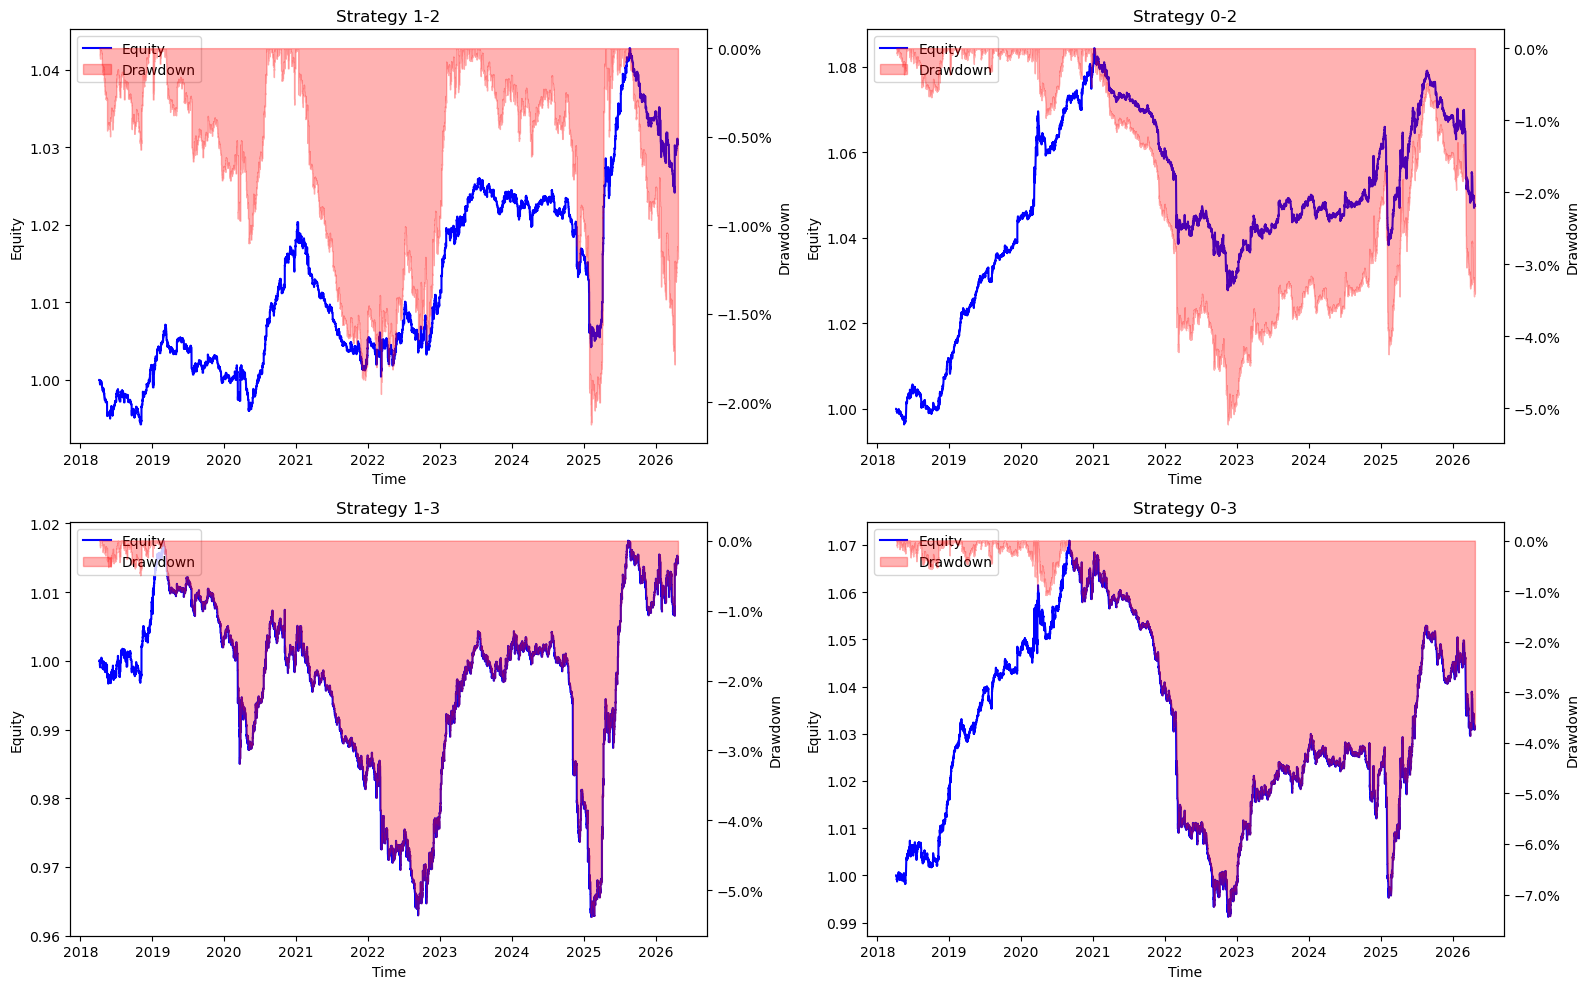

In [20]:
# Plot a grid of equity curves and their corresponding drawdowns
# for all strategies in the equity_curves collection
plot_equity_drawdown_grid(equity_curves)

# Conclusion

The inclusion of transaction costs reveal that the strategies do not remain profitable under realistic trading conditions.

All previously identified intraday patterns lose statistical significance once spreads, commissions, and slippage are accounted for. Returns become close to flat, while Sharpe ratios drop to low or negligible levels across all configurations:

- Strategy 1-2: Sharpe 4.24 → 0.39, Return 3.49% → 0.36%
- Strategy 0-2: Sharpe 3.03 → 0.38, Return 3.90% → 0.56%
- Strategy 1-3: Sharpe 2.51 → 0.12, Return 3.11% → 0.17%
- Strategy 0-3: Sharpe 2.22 → 0.20, Return 3.52% → 0.37%

This outcome is not unexpected and highlights several structural limitations of the current approach:

First, the strategy design is extremely simple, relying exclusively on fixed entry and exit times, with no additional filters applied to improve trade quality. This leads to a high number of trades, which significantly amplifies the impact of transaction costs. Potential enhancements include volatility-based filters to trade only during high-volatility regimes, simple technical filters (e.g. trend or mean-reversion confirmation from previous candles), or explicit risk management rules such as stop-loss and take-profit levels to control tail risk and improve payoff distribution.

Second, EUR/USD is a relatively low-volatility instrument on the H1 timeframe, resulting in small average trade size. In such a setting, even modest costs are sufficient to erode most of the edge.

Finally, strategy selection was based solely on the Sharpe ratio during in-sample optimization. This may have biased the selection toward strategies with smoother but smaller returns, rather than those with higher average trade profitability. A multi-objective selection framework (e.g. Sharpe combined with average trade or profit factor) could have been more appropriate.

Overall, while the raw intraday bias appears to exist in simplified form, it is not directly tradable in its current implementation once realistic execution constraints are considered. The result should therefore be interpreted as a **feature discovery step rather than a final trading strategy**.

## Next Direction

Future improvements should focus on increasing **average trade quality rather than trade frequency**, by introducing:

- Volatility regime filters  
- Simple directional or mean-reversion signals  
- Stop-loss / take-profit mechanisms  
- More robust multi-metric strategy selection criteria  